<style>
  .jp-RenderedImage,
  .jp-RenderedSVG {
    text-align: center;
  }

  .jp-RenderedImage img,
  .jp-RenderedSVG svg {
    display: block;
    margin-left: auto;
    margin-right: auto;
  }
</style>

I remember first discovering the amazing [Deep Implicit Layers tutorial](https://implicit-layers-tutorial.org/) by Zico Kolter, David Duvenaud, and Matt Johnson around 2021. I was trying to understand how neural networks could be used to learn dynamical systems from data (e.g. Neural ODEs), which to be honest, was quite novel to me. I was so used to thinking of neural networks as learning a function $NN(x;\theta)\approx f(x)$ that it never occurred to me that one could instead do $\frac{dx}{dt}=f(x)\approx NN(x;\theta)$. It looks like a small change, but it took me a while to wrap my head around that concept. 

Even more interesting to me was realizing that neural ODEs were just one instance of a broader class of models: implicit layers. Broadly speaking, the idea is that instead of learning the input-output map directly, you learn something that defines the map indirectly. That is, the output of a layer is defined not by a direct formula, but as the result of solving some underlying problem: following dynamics, finding a fixed point, minimizing an objective, or satisfying a constraint.

<div style="max-width: 80%; margin: 1.5rem auto 2rem auto; text-align: center;">
    <img
      src="{{ '/assets/img/tiny-convex-layer/zico-kolter-implicit-layer-slide.png' | relative_url }}"
      alt="Zico Kolter implicit layers tutorial slide"
      style="display: block; width: 100%; height: auto; margin: 0 auto; border-radius: 0.25rem;"
      loading="lazy"
    />
    <div class="caption" style="margin-top: 0.5rem; color: #808080; font-size: 0.875rem; line-height: 1.35; text-align: center;">
      Screenshot from Zico Kolter's implicit layers tutorial.
    </div>
</div>

In many cases, this means **placing a solver inside the model**. The layer then receives some inputs, solves an underlying problem, and returns the solution as its output. From the perspective of a neural network, this is just another layer with a forward pass. The tricky part is the backward pass: how do we propagate gradients through a solution that was obtained by running a solver?

This is very powerful because it gives us a general way to build layers defined through solvers, without manually deriving and implementing each case from scratch. In practice, one can often use these ideas without fully understanding all the machinery behind them. But learning how they work behind the scenes requires a fair amount of mathematics, which can make the topic feel intimidating at first.

Since I have recently been diving much deeper into these topics, I thought it would be useful to write a tutorial series that starts from the simplest example I can think of and builds up from there. The goal is to introduce some of the machinery behind implicit layers in a way that makes concepts like Lagrangians, KKT conditions, and implicit differentiation feel more intuitive (or at least more intuitive for me, and I hope for you as well!).

For this part I, I will start with the simplest version of that idea: a model gives a raw prediction, and an optimizer turns it into the closest prediction that satisfies a rule. We will focus on the optimizer itself, derive the Lagrangian and KKT conditions behind it, and set up the linear system that a future differentiable layer will solve.

## A simple motivating problem

Let's start with a very simple problem:

$$
x^\star(b)
=
\arg\min_x \|x-r\|_2^2
\quad \text{s.t.} \quad x_1+x_2=b
$$

This reads: given a point $r$, find $x^\star(b)$, the closest point to a given $r$ (minimizing the Euclidean distance), whose two coordinates add up to $b$. For example, let's say the given point is $r=(3.4,0.2)$, and $b=2$. This point is not *feasible*, since $r_1+r_2=3.6\neq 2$. We need to find the point $x^\star=(x^\star_1, x^\star_2)$ that is as close as possible to $r$, while satisfying the constraint $x^\star_1 + x^\star_2 = 2$.

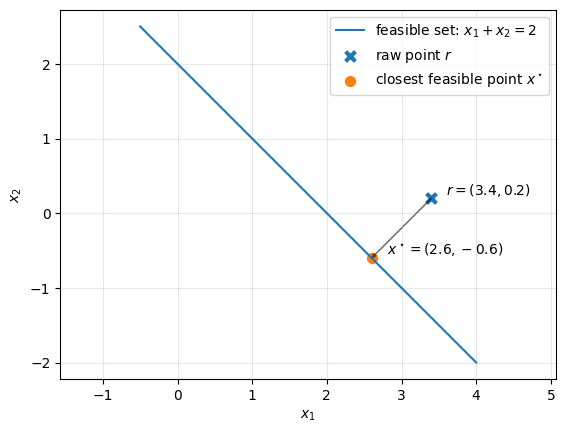

In [1]:
import numpy as np
import matplotlib.pyplot as plt

r = np.array([3.4, 0.2])
# closest point satisfying x1 + x2 = 2
x_star = np.array([2.6, -0.6])

x = np.linspace(-0.5, 4.0, 200)
y = 2 - x

plt.plot(x, y, label=r"feasible set: $x_1 + x_2 = 2$")
plt.scatter(*r, marker="x", s=50, linewidths=3, label=r"raw point $r$")
plt.scatter(*x_star, s=50, label=r"closest feasible point $x^\star$")

plt.arrow(
    r[0], r[1],
    x_star[0] - r[0],
    x_star[1] - r[1],
    length_includes_head=True,
    head_width=0.04,
    alpha=0.5
)

plt.text(3.60, 0.25, r"$r=(3.4,0.2)$")
plt.text(2.80, -0.55, r"$x^\star=(2.6,-0.6)$")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend();

This is basically a projection. Among all points on the line $x_1+x_2=b$, it selects the one closest to $r$. In this example, the Euclidean distance between $r=(3.4, 0.2)$ and the optimal projection $x^\star=(2.6, -0.6)$ is $\sqrt{0.8^2 + 0.8^2} \approx 1.13$. 

Now, the question is: can we learn some parameters of this optimization problem, like $b$, in a data-driven manner? We're not just interested in solving an optimization problem: we want to learn the parameters of the optimization problem so that we can use the output of the solver itself to compute a loss. Something like this:

$$
x
\;\longrightarrow\;
\boxed{\mathrm{NN}_\theta(x)}
\;\longrightarrow\;
r
\;\longrightarrow\;
\boxed{
\begin{array}{c}
\text{optimization layer} \\[6pt]
\begin{aligned}
x^\star(b)
&=
\arg\min_x \quad \|x-r\|_2^2 \\
&\phantom{=\,\arg\min_x \quad}\text{s.t.}\quad x_1+x_2=b
\end{aligned}
\end{array}
}
\;\longrightarrow\;
x^\star(b)
\;\longrightarrow\;
\mathcal{L}(x^\star(b),y)
$$

We will start by generating synthetic data using the constraint with a fixed (unknown) value. Let's say this is $x_1 + x_2 = 2$

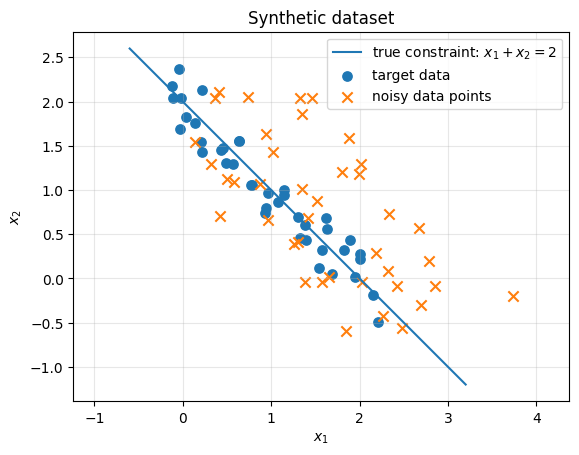

In [2]:
import numpy as np

np.random.seed(42)

n = 40
b_true = 2.0

# Create points near the *hidden* constraint line x1 + x2 = 2
x1 = np.linspace(-0.2, 2.2, n)
x2 = b_true - x1

# Ground truth points to predict (y)
y_clean = np.column_stack([x1, x2])
# Noisy predictions
y = y_clean + 0.15 * np.random.randn(n, 2)

# Raw points (data) with noise and bias
r = y + np.array([0.65, -0.25]) + 0.5 * np.random.randn(n, 2)

# Plot
x = np.linspace(-0.6, 3.2, 200)
line = b_true - x

plt.plot(x, line, label=r"true constraint: $x_1 + x_2 = 2$")
plt.scatter(y[:, 0], y[:, 1], s=45, label="target data")
plt.scatter(r[:, 0], r[:, 1], marker="x", s=55, label="noisy data points")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Synthetic dataset")
plt.legend();

Ok, we have a dataset now. We could discover the value of $b$ by just fitting a line through the blue target points, as you can see in the plot above, so the problem is trivial. However, we are going to learn $b$ in a more indirect way (implicitly): as the constraint line onto which we project the noisy data points, shown as orange crosses.

<div style="margin: 1.5rem 0; padding: 1rem 1.25rem; border-left: 4px solid #b8b8b8; background: rgba(128, 128, 128, 0.08); border-radius: 0.25rem;">
  <strong style="display: block; margin-bottom: 0.35rem;">Note:</strong>
  
  This toy problem is deliberately almost too simple. The projection has a closed-form formula, and if the only unknown is the constant $b$, we could estimate it directly from the targets. We do not need a solver for this specific case.

  But that simplicity is useful. Because the answer is easy to check, we can focus on the mechanism: how a constrained optimization problem becomes a solver, and how gradients can flow through its solution. Later, we will move to more interesting cases where the constraint is not just $x_1 + x_2 = b$, but something input-dependent, like $x_1 + x_2 = f_{\theta}(x)$ where $f_{\theta}$ can be non-linear. That is where the same machinery start to become more useful.

</div>

## Getting rid of the constraint with penalties

What makes this problem different from the optimization problems we usually see in machine learning is the constraint. If you have trained neural networks before, you are probably used to unconstrained optimization: define a loss, compute gradients, and update the parameters. The optimizer is allowed to search anywhere in parameter space.

Here, the variable $x$ is not allowed to take any value, it must satisfy $x_1 + x_2 = b$. Without this constraint, the problem is even simpler, since the closest point to $r$ is just $r$ itself.

So the first step is to ask whether we can transform this constrained problem into something we already know how to solve easily: an unconstrained problem. One natural idea is to keep the original objective, but add a term that punishes violations of the constraint.

$$
\arg\min_x \|x-r\|_2^2
\quad \text{s.t.} \quad x_1+x_2=b
$$

We can create a term that checks the magnitude of the violation. The constraint says $x_1+x_2-b = 0$. So, if $x_1+x_2-b$ is different from zero, we penalize it in proportion to the magnitude of the violation:
$$
\arg\min_x \|x-r\|_2^2 + \rho(x_1+x_2-b)^2
$$

The larger $\rho$ is, the more expensive it becomes to violate the constraint.

Did we solve the problem? Not yet. This penalizes constraint violations, but it does not guarantee that the constraint is satisfied exactly. For finite $\rho$, small violations are still allowed. To strictly enforce the constraint, we would need $\rho \to \infty$, but then the penalty term dominates the objective and the problem becomes numerically awkward.

Let's visualize that to make this concept clear. We will use a simple grid search:

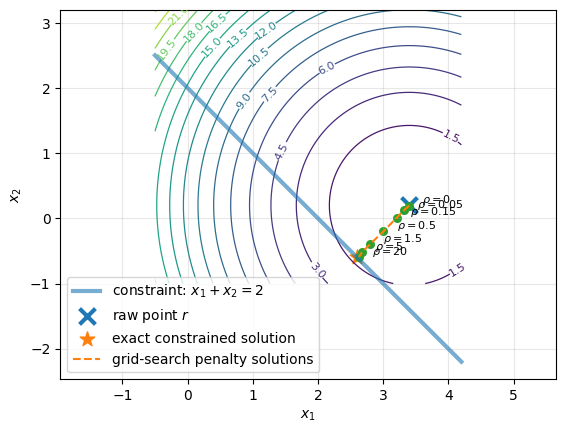

In [3]:
r = np.array([3.4, 0.2])
b = 2.0

# Candidate points x = (x1, x2)
x1 = np.linspace(-0.5, 4.2, 300)
x2 = np.linspace(-1.0, 3.2, 300)
Z1, Z2 = np.meshgrid(x1, x2)

# Original objective and constraint violation
distance = (Z1 - r[0])**2 + (Z2 - r[1])**2
violation = Z1 + Z2 - b

# Exact constrained solution, only for visual reference
x_exact = np.array([2.6, -0.6])

# Values of rho used for the geometry plot
rhos_for_plot = np.array([0, 0.05, 0.15, 0.5, 1.5, 5, 20])

# Values of rho used for the curve plot
rhos_for_curve = np.logspace(-3, 2, 100)


def solve_by_grid_search(rho):
    objective = distance + rho * violation**2

    row, col = np.unravel_index(
        np.argmin(objective),
        objective.shape
    )

    x = np.array([Z1[row, col], Z2[row, col]])
    d = distance[row, col]
    v = violation[row, col]
    p = rho * v**2

    return x, d, v, p


# Compute solutions for selected rho values
solutions = np.array([
    solve_by_grid_search(rho)[0]
    for rho in rhos_for_plot
])

# Compute curves for many rho values
curve_data = np.array([
    solve_by_grid_search(rho)[1:]
    for rho in rhos_for_curve
])

distance_terms = curve_data[:, 0]
violations = np.abs(curve_data[:, 1])
penalty_terms = curve_data[:, 2]


# Contours of the original distance objective
contours = plt.contour(Z1, Z2, distance, levels=20, linewidths=0.9)
plt.clabel(contours, inline=True, fontsize=8)

# Feasible line x1 + x2 = b
line_x = np.linspace(-0.5, 4.2, 300)
plt.plot(
    line_x,
    b - line_x,
    linewidth=3,
    alpha=0.6,
    label=r"constraint: $x_1+x_2=2$"
)

# Raw point and exact constrained solution
plt.scatter(
    r[0], r[1],
    s=130,
    marker="x",
    linewidths=3,
    label=r"raw point $r$"
)

plt.scatter(
    x_exact[0], x_exact[1],
    s=120,
    marker="*",
    label=r"exact constrained solution"
)

# Penalty solutions
plt.plot(
    solutions[:, 0],
    solutions[:, 1],
    "--",
    linewidth=1.5,
    label=r"grid-search penalty solutions"
)

plt.scatter(solutions[:, 0], solutions[:, 1], s=30)

for rho, x in zip(rhos_for_plot, solutions):
    plt.text(
        x[0] + 0.20,
        x[1] + 0.04,
        fr"$\rho={rho:g}$",
        fontsize=8
    )

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left");

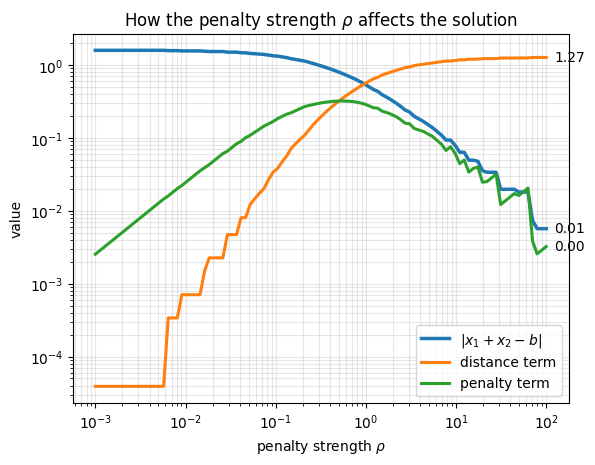

In [4]:
plt.loglog(
    rhos_for_curve,
    violations,
    linewidth=2.5,
    label=r"$|x_1+x_2-b|$"
)

plt.loglog(
    rhos_for_curve,
    distance_terms,
    linewidth=2.2,
    label=r"distance term"
)

plt.loglog(
    rhos_for_curve,
    penalty_terms,
    linewidth=2.2,
    label=r"penalty term"
)

# Add final-value labels
for y, name in [
    (violations, r"$|x_1+x_2-b|$"),
    (distance_terms, "distance"),
    (penalty_terms, "penalty"),
]:
    plt.annotate(
        f"{y[-1]:.2f}",
        xy=(rhos_for_curve[-1], y[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
    )

plt.xlabel(r"penalty strength $\rho$")
plt.ylabel("value")
plt.title(r"How the penalty strength $\rho$ affects the solution")
plt.grid(True, alpha=0.3, which="both")
plt.legend();

As $\rho$ increases, the penalty solution moves toward the constrained projection $x^\star=(2.6,-0.6)$, approaching the optimal distance term:

$$
\|x^\star-r\|_2^2
= (2.6-3.4)^2 + (-0.6-0.2)^2
= 0.8^2 + 0.8^2
= 1.28.
$$

In this toy example, we see how the penalized solution moves toward the constrained optimum. However, the penalty method does not enforce the constraint exactly for any finite value of $\rho$. It only makes violations of the constraint increasingly expensive.

Here, increasing $\rho$ pushes the solution very close to the true constrained projection, so the violation becomes visually negligible. But visually negligible is not the same as exactly feasible.

In general, to make the violation go to zero, we would need to take $\rho \to \infty$. At that point, the penalty term dominates the original objective, and the optimization problem becomes increasingly ill-conditioned.


## From penalties to exact constraints

So far, we have treated the constraint as something to punish. That is useful, but it is also a quick-and-dirty solution. We are not really solving the original constrained problem; we are solving a different problem that approximates it by penalizing infeasibility.

The penalty method added a squared cost for violating the constraint. For our toy constraint,

$$
x_1 + x_2 = b,
$$

the violation is

$$
x_1 + x_2 - b.
$$

So the penalty version was:

$$
\|x-r\|_2^2
+
\rho(x_1+x_2-b)^2.
$$

This made violations expensive, but it still allowed them.

Now let’s change the idea slightly. Instead of adding a squared penalty, we add a linear term in the violation:

$$
\|x-r\|_2^2
+
\lambda(x_1+x_2-b).
$$

For any fixed value of $\lambda$, this is still just an unconstrained optimization problem in $x$, we just dropped the squared term. The difference is that this new term **behaves differently** from the squared penalty. The squared penalty only cares about the size of the violation. If the violation is positive or negative, it does not matter; once we square it, both sides are punished the same way. **The linear term keeps the sign of the violation**. Depending on the value of $\lambda$, it can push the solution in one direction or the other. So instead of making violations more and more expensive, we can now ask a different question:

**Can we choose $\lambda$ so that the minimizer of this unconstrained problem lands exactly on the constraint?**

Note that I changed $\rho$ to $\lambda$ on purpose. The math looks almost identical, but the parameter $\rho$ was a penalty strength that we manually chose, whereas $\lambda$ will become an unknown that we determine from the constraint itself.

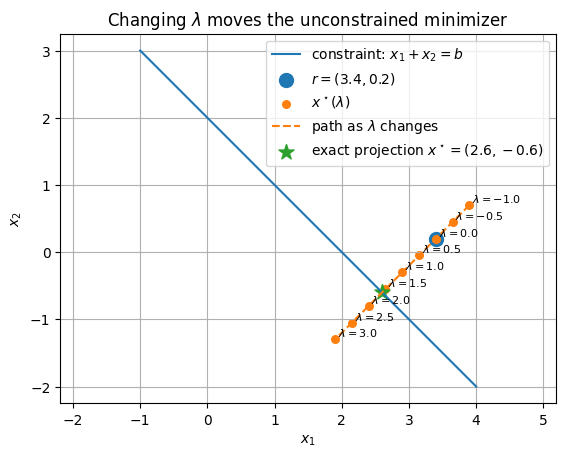

In [5]:
# Original example
r = np.array([3.4, 0.2])
b = 2.0

# Constraint: x1 + x2 = b
x = np.linspace(-1.0, 4.0, 200)
y = b - x

lambdas = np.linspace(-1.0, 3.0, 9)

solutions = np.array([
    r - (lam / 2) * np.array([1.0, 1.0])
    for lam in lambdas
])

# Exact lambda that makes x*(lambda) feasible:
# x1 + x2 = b
# r1 + r2 - lambda = b
# lambda = r1 + r2 - b
lambda_star = r.sum() - b
x_star = r - (lambda_star / 2) * np.array([1.0, 1.0])

plt.plot(x, y, label=r"constraint: $x_1 + x_2 = b$")
plt.scatter(r[0], r[1], s=100, label=r"$r=(3.4,0.2)$")
plt.scatter(solutions[:, 0], solutions[:, 1], s=30, label=r"$x^\star(\lambda)$")
plt.plot(
    solutions[:, 0],
    solutions[:, 1],
    linestyle="--",
    label=r"path as $\lambda$ changes"
)
plt.scatter(
    x_star[0],
    x_star[1],
    s=130,
    marker="*",
    label=rf"exact projection $x^\star=({x_star[0]:.1f},{x_star[1]:.1f})$"
)

for lam, x in zip(lambdas, solutions):
    plt.text(x[0] + 0.04, x[1] + 0.04, rf"$\lambda={lam:.1f}$", fontsize=8)

plt.axis("equal")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"Changing $\lambda$ moves the unconstrained minimizer")
plt.legend()
plt.grid(True);

You can see in the plot above that, as we increase the value of $\lambda$, there is a moment at which we *cross* the line. So there should be a value of $\lambda$ for which $x^\star(\lambda)$ lands directly on the line, and thus we **exactly** satisfy the constraint $x_1 + x_2 = b$.

So let’s define the new objective directly in terms of our toy constraint, including the value of $\lambda$:

$$
\mathcal{L}(x,\lambda)
=
\|x-r\|_2^2
+
\lambda(x_1+x_2-b)
$$

To make the notation more compact and general, we can replace $x_1 + x_2$ with vector notation:

$$
x =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix},
\quad
A =
\begin{bmatrix}
1 & 1
\end{bmatrix}.
$$

Then

$$
Ax =
\begin{bmatrix} 1 & 1 \end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
= x_1 + x_2.
$$

So we have the same thing, but more compact now:

$$
\mathcal{L}(x,\lambda)
=
\|x-r\|_2^2
+
\lambda(Ax-b).
$$

But now that the objective also depends on $\lambda$, we make explicit that the minimizer with respect to $x$ depends on the chosen value of $\lambda$. So for each fixed $\lambda$, we write

$$
x^\star(\lambda)
=
\arg\min_x \mathcal L(x,\lambda).
$$

This is what we represented in the plot above: for each $\lambda$, we have an $x^\star$ (orange dot), and there is one that lands exactly on the line.

## The Lagrangian

This augmented objective $\mathcal{L}(x,\lambda)$ is called the **Lagrangian** of the constrained problem. The new variable $\lambda$ is called a **Lagrange multiplier**.

In this example, $\lambda$ controls how strongly the constraint pushes back against the unconstrained minimizer. Unlike the quadratic penalty method, we are no longer trying to make a penalty parameter infinitely large. Instead, we are looking for the particular value of $\lambda$ that makes the minimizer satisfy the constraint exactly.

For a fixed $\lambda$, the Lagrangian is an unconstrained function of $x$:

$$
\mathcal{L}(x,\lambda)
=
\|x-r\|_2^2
+
\lambda(Ax-b).
$$

To find its minimizer, we set the gradient with respect to $x$ equal to zero:

$$
\nabla_x \mathcal{L}(x,\lambda)
=
2(x-r) + \lambda A^\top.
$$

Therefore,

$$
2(x-r) + \lambda A^\top = 0,
$$

which gives

$$
x^\star(\lambda)
=
r - \frac{\lambda}{2}A^\top.
$$

So each value of $\lambda$ gives a different unconstrained minimizer. For example, if $\lambda=1$ and

$$
r=
\begin{bmatrix}
3.4 \\
0.2
\end{bmatrix},
\qquad
A^\top=
\begin{bmatrix}
1 \\
1
\end{bmatrix},
$$

then

$$
x^\star(1)
=
\begin{bmatrix}
3.4 \\
0.2
\end{bmatrix}
-
\frac{1}{2}
\begin{bmatrix}
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
2.9 \\
-0.3
\end{bmatrix}.
$$

But we do not want just any unconstrained minimizer. We want the one that satisfies the constraint. Therefore we plug $x^\star(\lambda)$ into

$$
Ax=b.
$$

This gives

$$
A\left(r - \frac{\lambda}{2}A^\top\right)=b,
$$

so

$$
Ar - \frac{\lambda}{2}AA^\top = b.
$$

Solving for the value $\lambda^\star$ that makes the constraint hold,

$$
\lambda^\star
=
\frac{2(Ar-b)}{AA^\top}.
$$

For our toy example,

$$
A =
\begin{bmatrix}
1 & 1
\end{bmatrix},
\qquad
AA^\top = 2.
$$

Hence

$$
\lambda^\star = Ar-b.
$$

Since

$$
r=(3.4,0.2),
\qquad
b=2,
$$

we get

$$
\lambda^\star
=
3.4+0.2-2
=
1.6.
$$

Now we plug this value back into the minimizer formula:

$$
x^\star
=
r - \frac{\lambda^\star}{2}A^\top.
$$

Thus

$$
x^\star
=
\begin{bmatrix}
3.4 \\
0.2
\end{bmatrix}
-
\frac{1.6}{2}
\begin{bmatrix}
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
3.4 \\
0.2
\end{bmatrix}
-
0.8
\begin{bmatrix}
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
2.6 \\
-0.6
\end{bmatrix}.
$$

This point satisfies the constraint exactly:

$$
2.6 + (-0.6) = 2.
$$

## What the Lagrange multiplier is doing

Before, we found the optimal multiplier $\lambda^\star$ for the case of a single linear equality constraint:

$$
\lambda^\star
=
\frac{2(Ar-b)}{AA^\top}
=
2(AA^\top)^{-1}(Ar-b).
$$

This value $\lambda^\star$ tells us how much correction is needed in the direction perpendicular to the constraint. In our derivation, the constrained solution was

$$
x^\star
=
r - \frac{\lambda^\star}{2}A^\top.
$$

So $\lambda^\star$ controls the size of the step from the unconstrained minimizer $r$ back onto the constraint.

Notice that $\lambda^\star$ depends on $Ar-b$. This quantity is the constraint violation of the unconstrained point $r$.

If $Ar=b$, then $r$ already satisfies the constraint. In that case,

$$
Ar-b=0,
$$

so

$$
\lambda^\star=0.
$$

No correction is needed.

If $Ar-b$ is nonzero, then $r$ is outside the constraint. The multiplier $\lambda^\star$ scales this violation by the factor $2(AA^\top)^{-1}$.

So the multiplier tells us how strongly to push in the constraint-normal direction in order to cancel the violation $Ar-b$ and move $r$ onto the constraint.

## The Karush-Kuhn-Tucker (KKT) conditions

Without mentioning it, we have already used one of the central tools in constrained optimization: the **Karush-Kuhn-Tucker conditions**, usually called the **KKT conditions**.

The name sounds intimidating, but in this example the idea was simple. We looked for a pair $(x^\star,\lambda^\star)$ such that two things happen at the same time:

$$
x^\star \text{ minimizes the Lagrangian for } \lambda^\star,
$$

and

$$
x^\star \text{ satisfies the original constraint.}
$$

In equations, this became

$$
\nabla_x \mathcal{L}(x,\lambda)=0
$$

and

$$
Ax=b.
$$

That is already the KKT story for an equality-constrained problem.

Historically, these conditions are named after William Karush, Harold Kuhn, and Albert Tucker. Kuhn and Tucker published the result in the early 1950s, while Karush had already written a version of the conditions in an unpublished 1939 master’s thesis. Today, the name KKT recognizes all three.

More generally, KKT conditions describe what must be true at the solution of a constrained optimization problem.

For equality constraints, they say:

1. The solution must satisfy the constraint.
2. At the optimum, no small movement that stays on the constraint can improve the objective.
3. Equivalently, at the solution, the objective may still "want" to increase in some direction, but the constraint blocks that movement. The remaining push of the objective points off the feasible surface, where it is balanced by the gradients of the constraints.


For our projection problem, that balance appeared as

$$
2(x-r)+\lambda A^\top=0.
$$

The term $2(x-r)$ pulls the solution toward $r$. The term $\lambda A^\top$ is the correction coming from the constraint. At the optimum, these two effects balance.

## KKT conditions: are these sufficient?

In simple convex problems like this one, the situation is ideal. There is a **single global optimum**, and the KKT conditions are enough to guarantee that the point we found is the optimum.

This is why KKT works so well for this projection problem. The **objective is convex**, the **constraint set is convex**, and the regularity conditions are satisfied. So once we find a point that satisfies the KKT conditions, we are done: that point is the global solution.

For non-convex problems, the story is different.

In general, KKT conditions are **necessary** conditions for a local optimum (under some assumptions around regularity). This means: if a point is truly a **local solution**, then it should satisfy the KKT conditions.

But the reverse is not always true. A point can satisfy the KKT conditions and still fail to be the best global solution. It may only be a local optimum, or even just a stationary point, depending on the structure of the problem.

So the key distinction is:

* For convex problems, KKT conditions can certify a global optimum.
* For non-convex problems, KKT conditions usually only identify candidates that need further analysis.

Our projection problem is convex, so here KKT is enough to recover the exact solution.


## Extending to multiple equality constraints

Note that we already used matrix notation before on purpose, even though we were working with a single constraint $x_1+x_2=b.$

In that case, $A$ had only one row, so $AA^\top$ was just a $1\times 1$ matrix, equivalent to a scalar. By writing this in matrix notation, we do not need to change the formula when we move from one constraint to several constraints.

If we now have several equality constraints, we still write

$$
Ax=b.
$$

What changes is the meaning of the objects:

$$
A\in\mathbb{R}^{m\times n},
\qquad
x\in\mathbb{R}^n,
\qquad
b\in\mathbb{R}^m.
$$

Now each row of $A$ represents one equality constraint. Therefore the multiplier is no longer a single number, but a vector:

$$
\lambda\in\mathbb{R}^m.
$$

The Lagrangian constraint term becomes

$$
\lambda^\top(Ax-b),
$$

and the projection formula remains

$$
x^\star
=
r
-
A^\top(AA^\top)^{-1}(Ar-b).
$$

So the notation does not really change. What changes is that $AA^\top$ is now an $m\times m$ matrix, and $(AA^\top)^{-1}$ is a genuine matrix inverse rather than scalar division written in matrix form.

This formula assumes that the constraints are independent, meaning that the rows of $A$ are linearly independent. If not, $AA^\top$ is not invertible, and one uses a pseudoinverse instead.



## From the special case to general quadratic programs

The projection problem we just solved is already a quadratic program. It only looked special because the objective was written as a squared distance,

$$
\|x-r\|_2^2.
$$

A general quadratic objective in the variable $x$ has the form

$$
\frac12 x^\top Qx + q^\top x + d,
$$

where $Q$ controls the quadratic terms, $q$ controls the linear terms, and $d$ is a constant.

So a general equality-constrained quadratic program has the form

$$
\min_x
\frac12 x^\top Qx + q^\top x + d
\quad
\text{subject to}
\quad
Ax=b.
$$

The constant term $d$ does not affect the minimizer, so it is usually omitted:

$$
\min_x
\frac12 x^\top Qx + q^\top x
\quad
\text{subject to}
\quad
Ax=b.
$$

Now compare this with the projection problem:

$$
\min_x \|x-r\|_2^2
\quad
\text{subject to}
\quad
Ax=b.
$$

Expanding the squared distance gives

$$
\|x-r\|_2^2
=
(x-r)^\top(x-r)
=
x^\top x - 2r^\top x + r^\top r.
$$

This has exactly the same quadratic form:

$$
x^\top x - 2r^\top x + r^\top r.
$$

Matching terms with

$$
\frac12 x^\top Qx + q^\top x + d,
$$

we get

$$
Q = 2I,
\qquad
q = -2r,
\qquad
d = r^\top r.
$$

Since $d=r^\top r$ is constant with respect to $x$, it does not affect the minimizer.

Therefore, projection onto linear equality constraints is just a special case of the more general equality-constrained quadratic program

$$
\boxed{
\min_x
\frac12 x^\top Qx + q^\top x
\quad
\text{subject to}
\quad
Ax=b
}
$$

To solve it, we use the Lagrangian again, as we did before, but just using now this general form:

$$
\mathcal{L}(x,\lambda)
=
\frac12 x^\top Qx + q^\top x
+
\lambda^\top(Ax-b).
$$

Taking the derivative with respect to $x$ gives

$$
\nabla_x \mathcal{L}
=
Qx + q + A^\top \lambda.
$$

At the optimum,

$$
Qx + q + A^\top \lambda = 0,
$$

and the constraint must also hold:

$$
Ax=b.
$$

So the optimal point satisfies the system

$$
\boxed{
\begin{bmatrix}
Q & A^\top \\
A & 0
\end{bmatrix}
\begin{bmatrix}
x^\star \\
\lambda^\star
\end{bmatrix}
=
\begin{bmatrix}
-q \\
b
\end{bmatrix}
}
$$

This is called the KKT system. It generalizes the projection formula we derived earlier.



## What about inequalities?

In this post, we only looked at equality constraints. KKT can also be extended to handle inequality constraints.

The main new idea is that inequality constraints introduce additional conditions, including non-negative multipliers and complementary slackness. These tell us whether a constraint is active at the solution or irrelevant.

We will look at inequality constraints in a separate post.

## Summary and next steps

We started with a very small 2D problem: given a point $r$, find the closest point $x$ that satisfies a linear equality constraint. In our toy example, this meant projecting a point onto the line

$$
x_1 + x_2 = b.
$$

We first tried the quick-and-dirty penalty approach. That gave us useful intuition, but only an approximate solution for finite penalty values. Then we replaced the quadratic penalty with a linear term, arrived at the Lagrangian, and used the KKT conditions to recover the exact constrained solution.

The important result is that this was not just a trick for one line in 2D. The same idea extends to quadratic objectives with linear equality constraints:

$$
\min_x \frac{1}{2}x^\top Qx + q^\top x
\quad \text{subject to} \quad
Ax=b.
$$

For this class of problems, the KKT conditions give us a linear system:

$$
\begin{bmatrix}
Q & A^\top \\
A & 0
\end{bmatrix}
\begin{bmatrix}
x \\
\lambda
\end{bmatrix}
=
\begin{bmatrix}
-q \\
b
\end{bmatrix}.
$$

So we have turned a **constrained optimization problem** into **solving a linear system**.


In the next part, we will implement this as a small PyTorch layer. The layer will take the parameters of the quadratic problem, solve the KKT system, and return the constrained optimum $x^\star$.
